In [2]:
import pandas as pd
import seaborn as sns
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.append('../../scripts/3_signal_analysis')

from calculate import get_signals, log2fc
from save import save_signals

sys.path.append('../../scripts/2_comparative_analysis')

from compare import compare_pairwise

### **IAA/DMSO:** Plot log2fold change for peaks from DMSO/IAA experiment

In [42]:
#################### EXAMPLE USAGE ####################
################ PASTE YOUR PATHS INSTEAD #############
######### use cmd + shift + F to replace strain name ##########

output_dir = '../../results/signals_spikein/RDY466' # where plots are saved

# Paste outputs from notebooks/3_signals/calculate_signals.ipynb
DMSO_signals = pd.read_csv('../../results/signals_spikein/RDY466/RDY466_G1_DMSO_25_nC_spikein.csv', sep='\t', header=None)
IAA_signals = pd.read_csv('../../results/signals_spikein/RDY466/RDY466_G1_IAA_25_nC_spikein.csv', sep='\t', header=None)

# For labeling peaks
# To label peaks by overlapping with other peaks (e.g. ARS, MCM), add coordinates of them in .bed format
# Paste output from notebooks/2_comparative/compare_peaks.ipynb
DMSO_IAA_coord = '../../results/compared_peaks/RDY466_G1_DMSO_25_nC_RDY466_G1_IAA_25_nC/in_RDY466_G1_IAA_25_nC_RDY466_G1_DMSO_25_nC_ex.bed'

# Factor by which peaks will be labeled
factor_path = '../../data/references/ARS_late.bed'
factor_name = 'ARS late'



In [43]:
# Calculate log2fc
fc = pd.DataFrame()
fc['log2FC'] = log2fc(IAA_df=IAA_signals,
                     DMSO_df=DMSO_signals)

# Add info about peak signal in DMSO sample
fc['DMSO'] = DMSO_signals.sum(axis=0)

In [44]:
######### LABEL PEAKS ##########
factor = pd.read_csv(factor_path, names=['chr', 'start', 'end', 'center'], sep='\t')

# Load peaks from DMSO vs IAA comparison
DMSO_IAA = pd.read_csv(DMSO_IAA_coord, names=['chr', 'start', 'end', 'center'], sep='\t')

# Get peaks common for DMSO & IAA that only overlapping with factor
factor_DMSO_IAA = compare_pairwise({'factor': factor},
                                    {'DMSO_IAA': DMSO_IAA})

# Filter unnessary columns
coord = factor_DMSO_IAA.drop(factor_DMSO_IAA.columns[[1, 2, 3]], axis=1).dropna().reset_index(drop=True)
coord = coord.set_axis(['chr', 'start', 'end', 'center'], axis=1) # here only DMSOvsIAA peaks overlapping with factor

# Add label for each peak/row. 1 - is overlpaping with factor; 0 - is not.
fc['factor'] = (
    DMSO_IAA['center'].isin(coord['center'])
).astype(int)

/var/folders/lf/h7p_njl17ds2zx38ffpj5mb80000gw/T/ipykernel_1930/1088359264.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


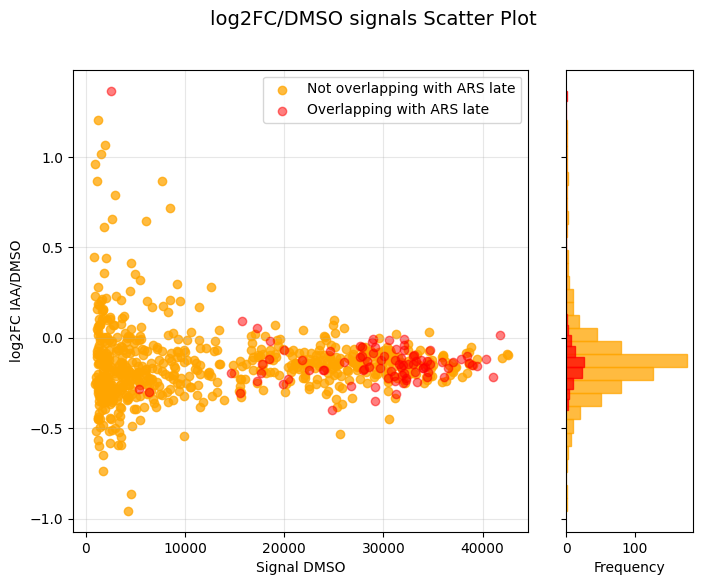

In [45]:
overlap_1 = fc[fc['factor'] == 1]
overlap_0 = fc[fc['factor'] == 0]


fig = plt.figure(figsize=(8, 6))
grid = plt.GridSpec(4, 4, hspace=0.3, wspace=0.3)
ax = fig.add_subplot(grid[0:4, 0:3])

# Histogram on right
hist_right_ax = fig.add_subplot(grid[0:4, 3], sharey=ax)

# Plot scatter for two sets of datapoints
ax.scatter(
    overlap_0['DMSO'],
    overlap_0['log2FC'],
    color='orange', # change color here for not overlap. points
    alpha=0.75,
    label=f'Not overlapping with {factor_name}'
)
ax.scatter(
    overlap_1['DMSO'],
    overlap_1['log2FC'],
    color='red', # change color here for overlap. points
    alpha=0.5,
    label=f'Overlapping with {factor_name}'
)

## LABELS ##
ax.set_xlabel('Signal DMSO')
ax.set_ylabel('log2FC IAA/DMSO')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Change scale if needed
#ax.set_xscale('log')

# Right histogram
hist_right_ax.hist(overlap_0['log2FC'], bins=30, alpha=0.75, color='orange', 
                   edgecolor='orange', orientation='horizontal')
hist_right_ax.set_xlabel('Frequency')
hist_right_ax.hist(overlap_1['log2FC'], bins=30, alpha=0.75, color='red', 
                   edgecolor='red', orientation='horizontal')
plt.setp(hist_right_ax.get_yticklabels(), visible=False)

plt.suptitle('log2FC/DMSO signals Scatter Plot', fontsize=14)
plt.tight_layout()

# Save figure with meaningful name
name = DMSO_IAA_coord.split('/')[-2]
plt.savefig(f'{output_dir}/{name}_scatter_{factor_name}.png', dpi=300)